# Naive Bayes Classifiers

## Real-World Scenario: Antimicrobial Compound Screening

A pharmaceutical lab screens candidate molecules for **antimicrobial activity** against drug-resistant bacteria. Each compound is described by a **molecular fingerprint** — a binary vector where each bit indicates the presence or absence of a chemical substructure (e.g., aromatic rings, hydroxyl groups, sulfonamide bridges).

The task: classify compounds into three categories based on their activity profile:

1. **Active** — strong antimicrobial effect, promising drug candidate
2. **Moderate** — partial activity, may need structural optimization
3. **Inactive** — no significant antimicrobial effect

With hundreds of substructure bits, modeling full feature correlations is impractical (a $D \times D$ covariance matrix would be enormous). Instead, we assume features are **conditionally independent** given the class — the **naive Bayes assumption**. Despite its simplicity, this approach works remarkably well for high-dimensional binary data and scales to thousands of features.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.special import softmax

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## Key Formulas from PML Chapter 9.3

**Naive Bayes assumption** — features are conditionally independent given the class (Eq. 9.46):

$$p(\mathbf{x} | y = c, \boldsymbol{\theta}) = \prod_{d=1}^{D} p(x_d | y = c, \theta_{dc})$$

**Posterior over class labels** (Eq. 9.47):

$$p(y = c | \mathbf{x}, \boldsymbol{\theta}) = \frac{p(y = c | \boldsymbol{\pi}) \prod_{d=1}^{D} p(x_d | y = c, \theta_{dc})}{\sum_{c'} p(y = c' | \boldsymbol{\pi}) \prod_{d=1}^{D} p(x_d | y = c', \theta_{dc'})}$$

**Bernoulli model** (for binary features): $p(x_d | y = c) = \text{Ber}(x_d | \theta_{dc})$ where $\theta_{dc} = P(x_d = 1 | y = c)$

**Gaussian model** (for real-valued features): $p(x_d | y = c) = \mathcal{N}(x_d | \mu_{dc}, \sigma^2_{dc})$

The model has only $O(CD)$ parameters — linear in the number of features — making it immune to the curse of dimensionality that plagues full covariance models with $O(CD^2)$ parameters.

## 1. Generate Synthetic Molecular Fingerprint Data

We simulate binary molecular fingerprints for 3 compound classes. Each feature represents the presence (`1`) or absence (`0`) of a chemical substructure. Different compound classes have different substructure frequencies.

In [20]:
# Simulation parameters
D = 20           # Number of molecular substructure bits
C = 3            # Number of classes
N = 600          # Total compounds screened

class_names = ['Active', 'Moderate', 'Inactive']
colors = ['#2196F3', '#FF9800', '#9E9E9E']

# True class priors (prevalence in screening library)
true_pi = np.array([0.15, 0.25, 0.60])  # Most compounds are inactive

# True Bernoulli parameters theta_dc = P(x_d = 1 | y = c)
# Each row is a class, each column is a feature
rng = np.random.RandomState(42)

# Active compounds: specific substructure signature
theta_active = np.array([0.9, 0.85, 0.8, 0.75, 0.7,   # Features 0-4: pharmacophore bits (high)
                         0.2, 0.15, 0.1, 0.15, 0.2,    # Features 5-9: toxicophore bits (low)
                         0.5, 0.5, 0.5, 0.5, 0.5,      # Features 10-14: common scaffolds
                         0.6, 0.65, 0.7, 0.3, 0.25])   # Features 15-19: misc structural features

# Moderate compounds: mixed signature
theta_moderate = np.array([0.5, 0.55, 0.45, 0.5, 0.4,
                           0.4, 0.35, 0.3, 0.35, 0.4,
                           0.5, 0.5, 0.5, 0.5, 0.5,
                           0.4, 0.45, 0.5, 0.5, 0.45])

# Inactive compounds: lack pharmacophore, may have toxicophore
theta_inactive = np.array([0.1, 0.15, 0.2, 0.15, 0.1,
                           0.7, 0.75, 0.8, 0.7, 0.65,
                           0.5, 0.5, 0.5, 0.5, 0.5,
                           0.3, 0.25, 0.2, 0.6, 0.65])

true_theta = np.array([theta_active, theta_moderate, theta_inactive])  # Shape: (C, D)

# Generate class labels from the prior
y = rng.choice(C, size=N, p=true_pi)

# Generate binary features from Bernoulli class-conditionals
X = np.zeros((N, D), dtype=int)
for n in range(N):
    X[n] = rng.binomial(1, true_theta[y[n]])

print(f"Generated {N} compounds with {D} substructure bits")
print(f"Class distribution:")
for c in range(C):
    print(f"  {class_names[c]:12s}: {(y == c).sum():4d} compounds ({(y == c).mean():.0%})")
print(f"\nSample fingerprint (compound 0, class={class_names[y[0]]}):\n  {X[0]}")

Generated 600 compounds with 20 substructure bits
Class distribution:
  Active      :  104 compounds (17%)
  Moderate    :  140 compounds (23%)
  Inactive    :  356 compounds (59%)

Sample fingerprint (compound 0, class=Moderate):
  [0 1 0 0 0 0 0 0 0 1 0 1 1 0 1 1 0 0 1 1]


In [21]:
X

array([[0, 1, 0, ..., 0, 1, 1],
       [0, 0, 0, ..., 0, 1, 1],
       [0, 0, 0, ..., 0, 0, 1],
       ...,
       [0, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 0, 0],
       [1, 0, 1, ..., 1, 0, 0]], shape=(600, 20))

## 2. Visualize Class-Conditional Densities

For each class $c$, the parameter $\theta_{dc}$ represents the probability that substructure $d$ is present. This is the "fingerprint signature" of each compound class.

/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_70191/1478968847.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


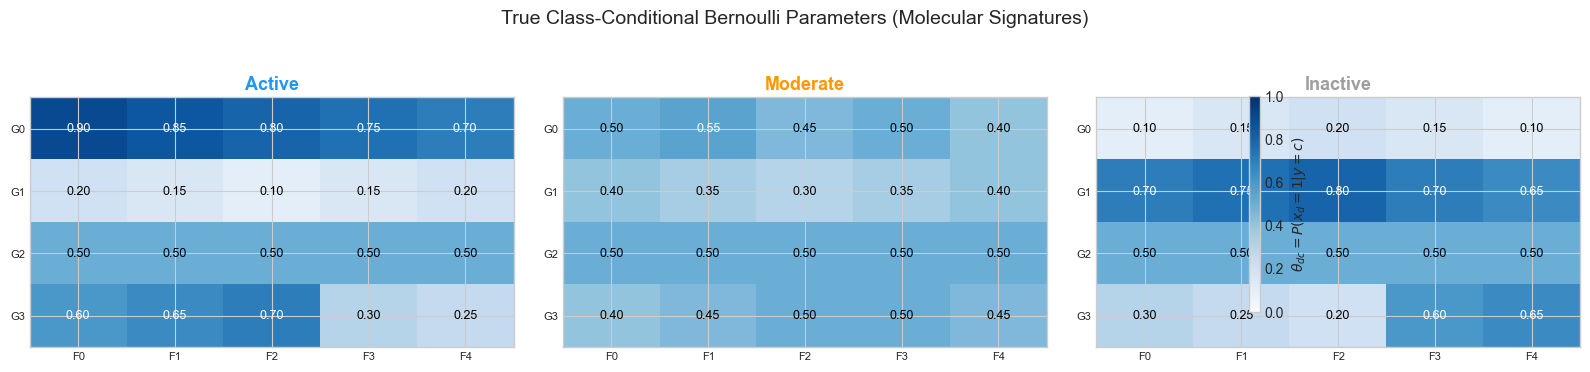

Active compounds: high pharmacophore bits (top row), low toxicophore bits (second row)
Inactive compounds: opposite pattern
Moderate compounds: intermediate values across all features
Middle rows (common scaffolds) have ~0.5 probability for all classes — uninformative.


In [3]:
# Visualize true theta parameters as heatmap (cf. Figure 9.6 in PML)
fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))

feature_labels = [
    'Aromatic ring', 'NH₂ group', 'OH group', 'C=O bond', 'Heterocycle',
    'Nitro group', 'Halide', 'Sulfone', 'Epoxide', 'Azide',
    'Benzene', 'Pyridine', 'Furan', 'Thiophene', 'Imidazole',
    'Amide bond', 'Ester', 'Alkene', 'Phosphate', 'Carboxyl'
]

for c in range(C):
    ax = axes[c]
    theta_grid = true_theta[c].reshape(4, 5)
    im = ax.imshow(theta_grid, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    
    # Annotate each cell
    for i in range(4):
        for j in range(5):
            val = theta_grid[i, j]
            color = 'white' if val > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9, color=color)
    
    ax.set_title(f'{class_names[c]}', fontsize=13, color=colors[c], fontweight='bold')
    ax.set_xticks(range(5))
    ax.set_xticklabels([f'F{i}' for i in range(5)], fontsize=8)
    ax.set_yticks(range(4))
    ax.set_yticklabels([f'G{i}' for i in range(4)], fontsize=8)

fig.colorbar(im, ax=axes, label='$\\theta_{dc} = P(x_d = 1 | y = c)$', shrink=0.8)
plt.suptitle('True Class-Conditional Bernoulli Parameters (Molecular Signatures)', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print("Active compounds: high pharmacophore bits (top row), low toxicophore bits (second row)")
print("Inactive compounds: opposite pattern")
print("Moderate compounds: intermediate values across all features")
print("Middle rows (common scaffolds) have ~0.5 probability for all classes — uninformative.")

## 3. Model Fitting via Maximum Likelihood (Section 9.3.2)

The log-likelihood decomposes into independent terms (Eq. 9.50–9.51):

$$\log p(\mathcal{D} | \boldsymbol{\theta}) = \underbrace{\log p(\mathcal{D}_y | \boldsymbol{\pi})}_{\text{prior term}} + \sum_{c} \sum_{d} \underbrace{\log p(\mathcal{D}_{dc} | \theta_{dc})}_{\text{feature terms}}$$

This decomposition means we can estimate each parameter independently:

**Class prior MLE**: $\hat{\pi}_c = N_c / N$

**Bernoulli MLE** (Eq. 9.53): $\hat{\theta}_{dc} = N_{dc} / N_c$

where $N_{dc}$ is the number of examples in class $c$ where feature $d$ is 1, and $N_c$ is the total number of examples in class $c$.

This is simply the empirical fraction — counting and dividing. No optimization needed!

In [4]:
def fit_bernoulli_nb(X, y, C):
    """
    Fit Bernoulli Naive Bayes via MLE (Eqs. 9.52-9.53).
    
    Returns:
        pi_hat: (C,) class priors
        theta_hat: (C, D) Bernoulli parameters
    """
    N, D = X.shape
    pi_hat = np.zeros(C)
    theta_hat = np.zeros((C, D))
    
    for c in range(C):
        mask = y == c
        Nc = mask.sum()
        
        # Class prior: pi_c = N_c / N
        pi_hat[c] = Nc / N
        
        # Bernoulli MLE: theta_dc = N_dc / N_c
        # N_dc = number of times feature d is 1 in class c
        theta_hat[c] = X[mask].sum(axis=0) / Nc
    
    return pi_hat, theta_hat


# Fit the model
pi_hat, theta_hat = fit_bernoulli_nb(X, y, C)

print("MLE Parameter Estimates")
print("=" * 55)
print(f"\nClass priors:")
for c in range(C):
    print(f"  pi_{class_names[c]:8s} = {pi_hat[c]:.3f}  (true: {true_pi[c]:.3f})")

print(f"\nBernoulli parameters (first 5 features):")
print(f"  {'Feature':>10s}", end='')
for c in range(C):
    print(f"  {class_names[c]:>10s}", end='')
print()
for d in range(5):
    print(f"  {'d=' + str(d):>10s}", end='')
    for c in range(C):
        print(f"  {theta_hat[c, d]:.3f}/{true_theta[c, d]:.2f}", end='')
    print()

MLE Parameter Estimates

Class priors:
  pi_Active   = 0.173  (true: 0.150)
  pi_Moderate = 0.233  (true: 0.250)
  pi_Inactive = 0.593  (true: 0.600)

Bernoulli parameters (first 5 features):
     Feature      Active    Moderate    Inactive
         d=0  0.894/0.90  0.500/0.50  0.096/0.10
         d=1  0.856/0.85  0.564/0.55  0.132/0.15
         d=2  0.808/0.80  0.450/0.45  0.230/0.20
         d=3  0.769/0.75  0.471/0.50  0.146/0.15
         d=4  0.692/0.70  0.357/0.40  0.098/0.10


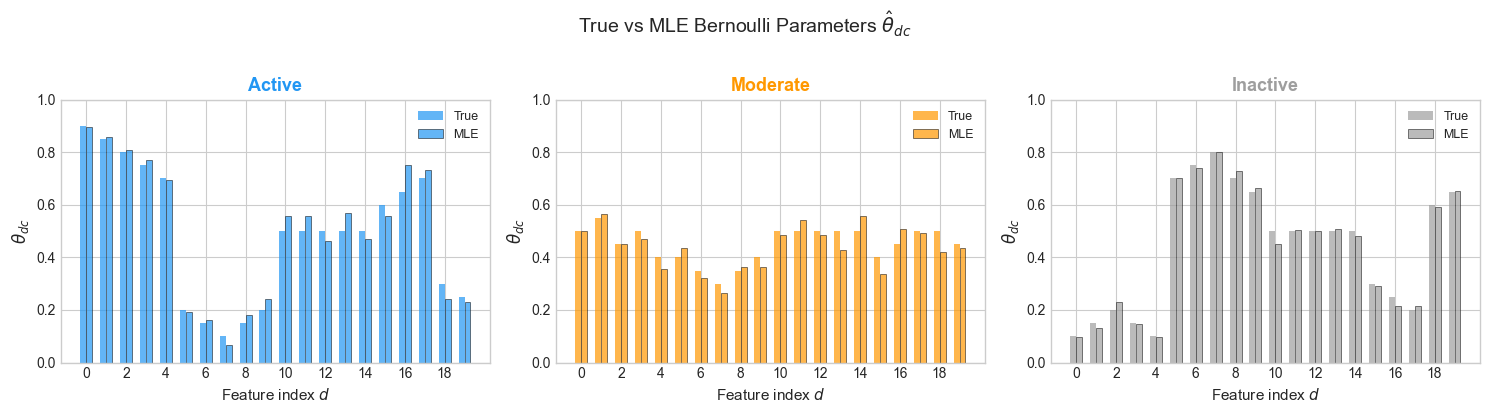

Mean absolute error |theta_hat - theta_true|: 0.0266
The MLE estimates are close to the true values with 600 samples.


In [5]:
# Compare estimated vs true parameters
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for c in range(C):
    ax = axes[c]
    ax.bar(np.arange(D) - 0.15, true_theta[c], width=0.3, alpha=0.7, color=colors[c], label='True')
    ax.bar(np.arange(D) + 0.15, theta_hat[c], width=0.3, alpha=0.7, color=colors[c],
           edgecolor='black', linewidth=0.5, label='MLE')
    ax.set_xlabel('Feature index $d$', fontsize=11)
    ax.set_ylabel('$\\theta_{dc}$', fontsize=12)
    ax.set_title(f'{class_names[c]}', fontsize=13, color=colors[c], fontweight='bold')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.set_xticks(range(0, D, 2))

plt.suptitle('True vs MLE Bernoulli Parameters $\\hat{\\theta}_{dc}$', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Mean absolute error
mae = np.abs(theta_hat - true_theta).mean()
print(f"Mean absolute error |theta_hat - theta_true|: {mae:.4f}")
print("The MLE estimates are close to the true values with 600 samples.")

## 4. Classification with Naive Bayes

To classify a new compound, we compute the posterior (Eq. 9.47) for each class:

$$p(y = c | \mathbf{x}) \propto \pi_c \prod_{d=1}^{D} \theta_{dc}^{x_d} (1 - \theta_{dc})^{1 - x_d}$$

In practice we work in log-space to avoid numerical underflow:

$$\log p(y = c | \mathbf{x}) = \log \pi_c + \sum_{d=1}^{D} \left[ x_d \log \theta_{dc} + (1 - x_d) \log(1 - \theta_{dc}) \right] + \text{const}$$

In [6]:
def predict_bernoulli_nb(X, pi, theta, C):
    """
    Predict class labels using Bernoulli Naive Bayes (Eq. 9.47).
    Works in log-space for numerical stability.
    
    Returns:
        preds: (N,) predicted class labels
        log_posteriors: (N, C) unnormalized log posteriors
    """
    N = X.shape[0]
    log_posteriors = np.zeros((N, C))
    
    for c in range(C):
        # log pi_c
        log_prior = np.log(pi[c])
        
        # sum_d [ x_d * log(theta_dc) + (1-x_d) * log(1-theta_dc) ]
        log_likelihood = (X * np.log(theta[c]) + (1 - X) * np.log(1 - theta[c])).sum(axis=1)
        
        log_posteriors[:, c] = log_prior + log_likelihood
    
    preds = np.argmax(log_posteriors, axis=1)
    return preds, log_posteriors


# Classify training data
preds_train, log_post_train = predict_bernoulli_nb(X, pi_hat, theta_hat, C)
train_acc = (preds_train == y).mean()

# Generate test data
N_test = 1000
y_test = rng.choice(C, size=N_test, p=true_pi)
X_test = np.zeros((N_test, D), dtype=int)
for n in range(N_test):
    X_test[n] = rng.binomial(1, true_theta[y_test[n]])

preds_test, log_post_test = predict_bernoulli_nb(X_test, pi_hat, theta_hat, C)
test_acc = (preds_test == y_test).mean()

print(f"Training accuracy: {train_acc:.1%}")
print(f"Test accuracy:     {test_acc:.1%}")

# Confusion matrix
print(f"\nConfusion matrix (rows = true, cols = predicted):")
conf = np.zeros((C, C), dtype=int)
for c_true in range(C):
    for c_pred in range(C):
        conf[c_true, c_pred] = ((y_test == c_true) & (preds_test == c_pred)).sum()

print(f"{'':>12s}", end='')
for c in range(C):
    print(f"  {class_names[c]:>10s}", end='')
print()
for c_true in range(C):
    print(f"{class_names[c_true]:>12s}", end='')
    for c_pred in range(C):
        print(f"  {conf[c_true, c_pred]:10d}", end='')
    print()

Training accuracy: 90.0%
Test accuracy:     86.3%

Confusion matrix (rows = true, cols = predicted):
                  Active    Moderate    Inactive
      Active         113          27           0
    Moderate          37         186          49
    Inactive           0          24         564


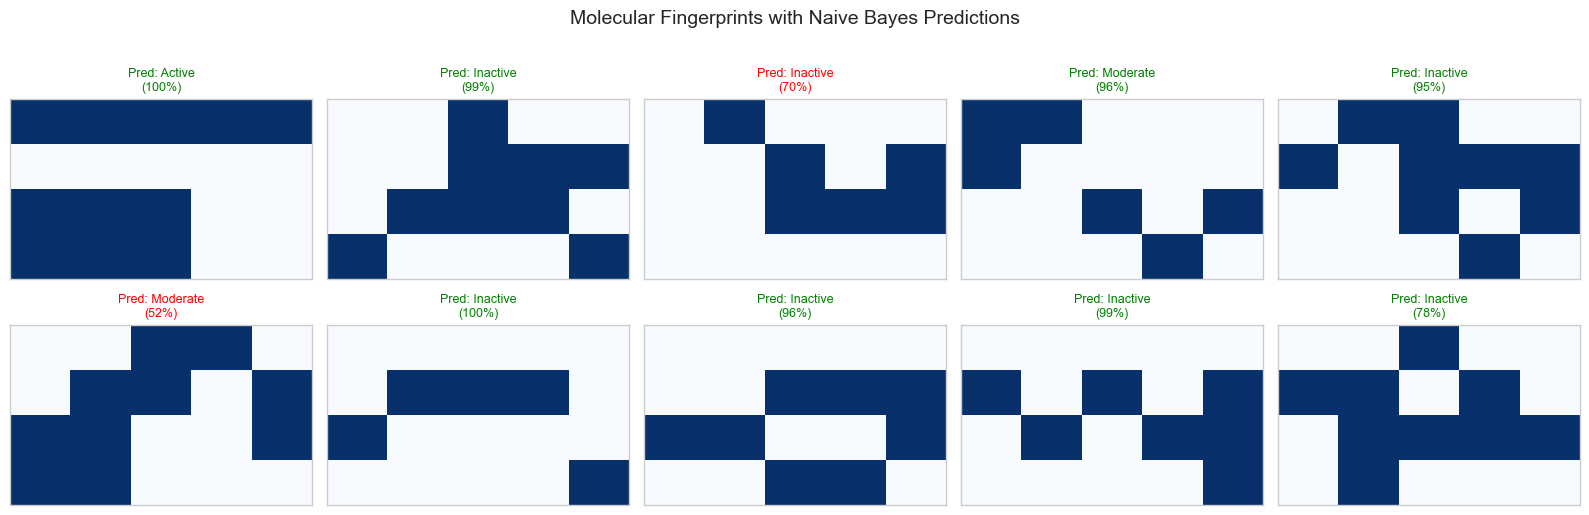

In [7]:
# Visualize some predictions
fig, axes = plt.subplots(2, 5, figsize=(16, 5))

# Pick 10 random test compounds
indices = rng.choice(N_test, 10, replace=False)

for idx, ax in zip(indices, axes.flat):
    # Show fingerprint as a color strip
    fp = X_test[idx].reshape(4, 5)
    ax.imshow(fp, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    
    # Normalize log posteriors to probabilities
    log_p = log_post_test[idx]
    probs = softmax(log_p)
    
    true_label = class_names[y_test[idx]]
    pred_label = class_names[preds_test[idx]]
    correct = y_test[idx] == preds_test[idx]
    
    title_color = 'green' if correct else 'red'
    ax.set_title(f'Pred: {pred_label}\n({probs[preds_test[idx]]:.0%})',
                 fontsize=9, color=title_color)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Molecular Fingerprints with Naive Bayes Predictions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
print(log_post_test[idx])
print(softmax(log_post_test[idx]))

[-20.74358892 -14.90921294 -13.61360071]
[6.28253728e-04 2.14769384e-01 7.84602362e-01]


## 5. The Zero-Count Problem and Laplace Smoothing (Section 9.3.3)

A critical issue with MLE: if a feature never appears in a class ($N_{dc} = 0$), then $\hat{\theta}_{dc} = 0$. A single zero in the product $\prod_d \theta_{dc}^{x_d}$ makes the entire class likelihood zero — the model will **never** predict that class for any input with that feature.

**Bayesian solution**: use a Dirichlet prior $p(\boldsymbol{\theta}_{dc}) = \text{Dir}(\boldsymbol{\theta}_{dc} | \boldsymbol{\beta}_{dc})$. With conjugate priors, the posterior mean (Eq. 9.57–9.58) becomes:

$$\bar{\theta}_{dc} = \frac{\tilde{\beta}_{dc1} + N_{dc1}}{\tilde{\beta}_{dc0} + N_{dc0} + \tilde{\beta}_{dc1} + N_{dc1}}$$

Setting $\tilde{\beta}_{dc0} = \tilde{\beta}_{dc1} = 1$ gives **Laplace smoothing** (add-one smoothing):

$$\bar{\theta}_{dc} = \frac{1 + N_{dc}}{2 + N_c}$$

This ensures no parameter is ever exactly 0 or 1.

In [8]:
# Demonstrate the zero-count problem with small data
N_small = 20
X_small = X[:N_small]
y_small = y[:N_small]

print(f"Small dataset: {N_small} samples")
for c in range(C):
    print(f"  {class_names[c]}: {(y_small == c).sum()} samples")

# Fit MLE on small data
pi_small, theta_small = fit_bernoulli_nb(X_small, y_small, C)

# Count zeros in theta estimates
n_zeros = (theta_small == 0).sum()
n_ones = (theta_small == 1).sum()
print(f"\nMLE estimates:")
print(f"  Exact zeros (theta=0): {n_zeros}")
print(f"  Exact ones  (theta=1): {n_ones}")
print(f"  Total parameters: {C * D}")
print(f"\nThese zeros/ones cause log(0) = -inf in the likelihood!")

Small dataset: 20 samples
  Active: 2 samples
  Moderate: 8 samples
  Inactive: 10 samples

MLE estimates:
  Exact zeros (theta=0): 8
  Exact ones  (theta=1): 7
  Total parameters: 60

These zeros/ones cause log(0) = -inf in the likelihood!


In [9]:
def fit_bernoulli_nb_laplace(X, y, C, alpha=1.0):
    """
    Fit Bernoulli Naive Bayes with Laplace smoothing (Eq. 9.58).
    
    alpha=1.0: add-one smoothing (Laplace)
    alpha=0.0: MLE (no smoothing)
    
    theta_dc = (alpha + N_dc) / (2*alpha + N_c)
    """
    N, D = X.shape
    pi_hat = np.zeros(C)
    theta_hat = np.zeros((C, D))
    
    for c in range(C):
        mask = y == c
        Nc = mask.sum()
        pi_hat[c] = Nc / N
        
        # Laplace smoothing: (alpha + N_dc) / (2*alpha + N_c)
        N_dc = X[mask].sum(axis=0)  # Count of x_d=1 in class c
        theta_hat[c] = (alpha + N_dc) / (2 * alpha + Nc)
    
    return pi_hat, theta_hat


# Compare MLE vs Laplace smoothing on small data
pi_laplace, theta_laplace = fit_bernoulli_nb_laplace(X_small, y_small, C, alpha=1.0)

print("Effect of Laplace smoothing (class 0, first 10 features):")
print(f"{'Feature':>8s}  {'MLE':>8s}  {'Laplace':>8s}  {'True':>8s}")
print("-" * 40)
for d in range(10):
    mle_val = theta_small[0, d]
    lap_val = theta_laplace[0, d]
    true_val = true_theta[0, d]
    flag = ' ⚠' if mle_val == 0 or mle_val == 1 else ''
    print(f"{d:>8d}  {mle_val:>8.3f}  {lap_val:>8.3f}  {true_val:>8.2f}{flag}")

Effect of Laplace smoothing (class 0, first 10 features):
 Feature       MLE   Laplace      True
----------------------------------------
       0     0.500     0.500      0.90
       1     1.000     0.750      0.85 ⚠
       2     1.000     0.750      0.80 ⚠
       3     1.000     0.750      0.75 ⚠
       4     1.000     0.750      0.70 ⚠
       5     0.500     0.500      0.20
       6     0.500     0.500      0.15
       7     0.500     0.500      0.10
       8     0.000     0.250      0.15 ⚠
       9     0.000     0.250      0.20 ⚠


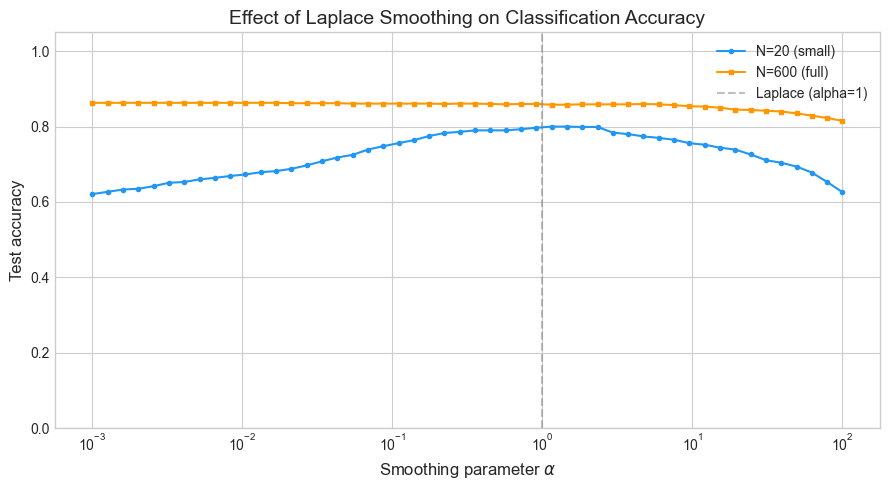

With small data, smoothing has a dramatic effect — too little smoothing
causes zeros that break the model, while too much smoothing pushes all
parameters toward 0.5, destroying discriminative information.
With enough data, the model is robust across a wide range of alpha.


In [10]:
# Effect of smoothing strength on test accuracy
alphas = np.logspace(-3, 2, 50)
accs_small = []
accs_full = []

for alpha in alphas:
    # Small data: smoothing matters a lot
    pi_s, theta_s = fit_bernoulli_nb_laplace(X_small, y_small, C, alpha=alpha)
    # Clip to avoid log(0)
    theta_s = np.clip(theta_s, 1e-10, 1 - 1e-10)
    preds_s, _ = predict_bernoulli_nb(X_test, pi_s, theta_s, C)
    accs_small.append((preds_s == y_test).mean())
    
    # Full data: smoothing matters less
    pi_f, theta_f = fit_bernoulli_nb_laplace(X, y, C, alpha=alpha)
    preds_f, _ = predict_bernoulli_nb(X_test, pi_f, theta_f, C)
    accs_full.append((preds_f == y_test).mean())

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(alphas, accs_small, 'o-', color=colors[0], markersize=3, label=f'N={N_small} (small)')
ax.semilogx(alphas, accs_full, 's-', color=colors[1], markersize=3, label=f'N={N} (full)')
ax.axvline(1.0, color='gray', linestyle='--', alpha=0.5, label='Laplace (alpha=1)')
ax.set_xlabel('Smoothing parameter $\\alpha$', fontsize=12)
ax.set_ylabel('Test accuracy', fontsize=12)
ax.set_title('Effect of Laplace Smoothing on Classification Accuracy', fontsize=14)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("With small data, smoothing has a dramatic effect — too little smoothing")
print("causes zeros that break the model, while too much smoothing pushes all")
print("parameters toward 0.5, destroying discriminative information.")
print("With enough data, the model is robust across a wide range of alpha.")

## 6. Gaussian Naive Bayes (Section 9.3.1)

For **continuous** features $x_d \in \mathbb{R}$, we use a univariate Gaussian for each class-conditional density:

$$p(x_d | y = c) = \mathcal{N}(x_d | \mu_{dc}, \sigma^2_{dc})$$

**MLE estimates** (Eqs. 9.54–9.55):

$$\hat{\mu}_{dc} = \frac{1}{N_c} \sum_{n: y_n = c} x_{nd}, \qquad \hat{\sigma}^2_{dc} = \frac{1}{N_c} \sum_{n: y_n = c} (x_{nd} - \hat{\mu}_{dc})^2$$

This is equivalent to GDA with **diagonal covariance matrices** — each feature is modeled independently.

In [11]:
# Generate continuous biomarker data for the same 3 compound classes
# Features: molecular weight, logP (lipophilicity), polar surface area, H-bond donors
D_cont = 4
feature_names_cont = ['Mol. Weight', 'logP', 'Polar SA', 'H-bond donors']

# True parameters: mean and variance per (class, feature)
true_mu_cont = np.array([
    [350, 2.5, 80, 3],     # Active: moderate MW, good lipophilicity
    [420, 3.5, 110, 5],    # Moderate: larger, more polar
    [550, 1.0, 150, 7],    # Inactive: too large, too polar
], dtype=float)

true_sigma2_cont = np.array([
    [2500, 0.5, 200, 1.0],
    [3000, 0.8, 300, 1.5],
    [4000, 1.0, 400, 2.0],
], dtype=float)

# Generate continuous data
N_cont = 600
y_cont = rng.choice(C, size=N_cont, p=true_pi)
X_cont = np.zeros((N_cont, D_cont))
for n in range(N_cont):
    for d in range(D_cont):
        X_cont[n, d] = rng.normal(true_mu_cont[y_cont[n], d],
                                   np.sqrt(true_sigma2_cont[y_cont[n], d]))


def fit_gaussian_nb(X, y, C):
    """
    Fit Gaussian Naive Bayes via MLE (Eqs. 9.54-9.55).
    
    Returns:
        pi_hat: (C,) class priors
        mu_hat: (C, D) means
        sigma2_hat: (C, D) variances
    """
    N, D = X.shape
    pi_hat = np.zeros(C)
    mu_hat = np.zeros((C, D))
    sigma2_hat = np.zeros((C, D))
    
    for c in range(C):
        mask = y == c
        Nc = mask.sum()
        pi_hat[c] = Nc / N
        
        # MLE mean: mu_dc = (1/Nc) * sum x_nd
        mu_hat[c] = X[mask].mean(axis=0)
        
        # MLE variance: sigma2_dc = (1/Nc) * sum (x_nd - mu_dc)^2
        sigma2_hat[c] = ((X[mask] - mu_hat[c]) ** 2).mean(axis=0)
    
    return pi_hat, mu_hat, sigma2_hat


def predict_gaussian_nb(X, pi, mu, sigma2, C):
    """Predict using Gaussian NB in log-space."""
    N = X.shape[0]
    log_posteriors = np.zeros((N, C))
    
    for c in range(C):
        log_prior = np.log(pi[c])
        # sum_d [ -0.5*log(2*pi*sigma2) - 0.5*(x_d - mu_d)^2 / sigma2 ]
        log_likelihood = -0.5 * np.sum(np.log(2 * np.pi * sigma2[c])) \
                         - 0.5 * np.sum((X - mu[c]) ** 2 / sigma2[c], axis=1)
        log_posteriors[:, c] = log_prior + log_likelihood
    
    preds = np.argmax(log_posteriors, axis=1)
    return preds, log_posteriors


# Fit and evaluate
pi_gnb, mu_gnb, sigma2_gnb = fit_gaussian_nb(X_cont, y_cont, C)

# Test data
y_test_cont = rng.choice(C, size=N_test, p=true_pi)
X_test_cont = np.zeros((N_test, D_cont))
for n in range(N_test):
    for d in range(D_cont):
        X_test_cont[n, d] = rng.normal(true_mu_cont[y_test_cont[n], d],
                                        np.sqrt(true_sigma2_cont[y_test_cont[n], d]))

preds_gnb, _ = predict_gaussian_nb(X_test_cont, pi_gnb, mu_gnb, sigma2_gnb, C)
gnb_acc = (preds_gnb == y_test_cont).mean()

print(f"Gaussian Naive Bayes test accuracy: {gnb_acc:.1%}")

Gaussian Naive Bayes test accuracy: 96.9%


In [28]:
mask = y == 2
X_cont[mask]

array([[ 5.65741092e+02,  1.93414323e-01,  1.94776658e+02,
         6.22549943e+00],
       [ 4.76184801e+02,  4.86711747e+00,  1.24355876e+02,
         4.37949790e+00],
       [ 3.88336655e+02,  6.13329741e+00,  1.44189746e+02,
         5.37167511e+00],
       ...,
       [ 5.13778766e+02,  6.09371475e-01,  1.64731525e+02,
         6.75986202e+00],
       [ 5.23590804e+02, -3.37322821e-01,  1.52038123e+02,
         6.22665529e+00],
       [ 5.33999472e+02,  3.31636302e+00,  7.07355216e+01,
         6.16371772e+00]], shape=(356, 4))

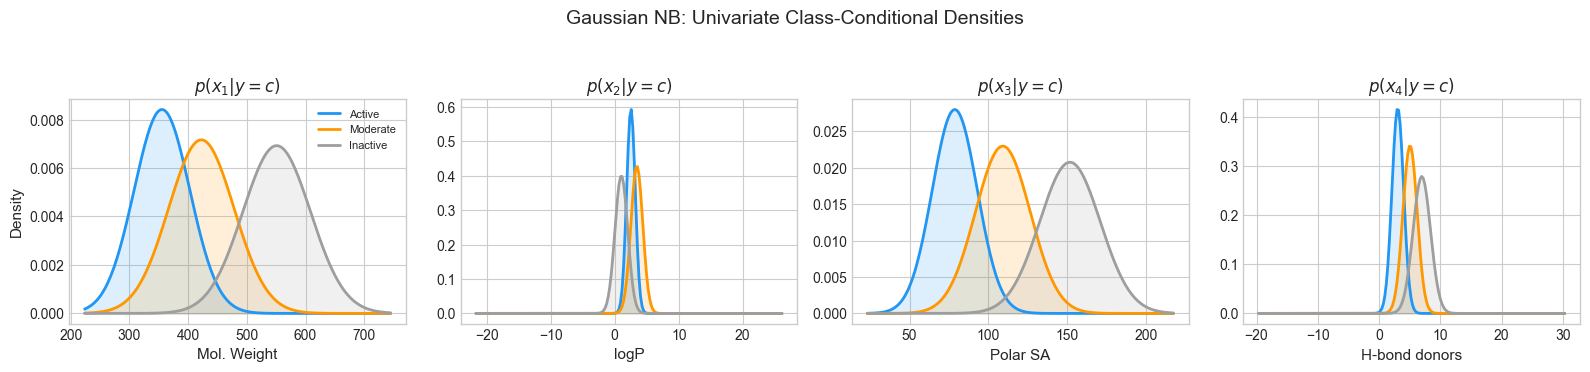

Each feature has its own Gaussian per class — no cross-feature correlations modeled.
This is equivalent to GDA with diagonal covariance matrices (Section 9.2.4.2).


In [12]:
# Visualize Gaussian NB: class-conditional densities for each feature
fig, axes = plt.subplots(1, D_cont, figsize=(16, 3.5))

for d in range(D_cont):
    ax = axes[d]
    x_range = np.linspace(X_cont[:, d].min() - 20, X_cont[:, d].max() + 20, 200)
    
    for c in range(C):
        # Plot class-conditional Gaussian
        pdf = (1 / np.sqrt(2 * np.pi * sigma2_gnb[c, d])) * \
              np.exp(-0.5 * (x_range - mu_gnb[c, d])**2 / sigma2_gnb[c, d])
        ax.plot(x_range, pdf, color=colors[c], linewidth=2, label=class_names[c])
        ax.fill_between(x_range, pdf, alpha=0.15, color=colors[c])
    
    ax.set_xlabel(feature_names_cont[d], fontsize=11)
    ax.set_ylabel('Density' if d == 0 else '', fontsize=11)
    ax.set_title(f'$p(x_{d+1} | y=c)$', fontsize=12)
    if d == 0:
        ax.legend(fontsize=8)

plt.suptitle('Gaussian NB: Univariate Class-Conditional Densities', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print("Each feature has its own Gaussian per class — no cross-feature correlations modeled.")
print("This is equivalent to GDA with diagonal covariance matrices (Section 9.2.4.2).")

## 7. Connection to Logistic Regression (Section 9.3.4)

The naive Bayes posterior has the same functional form as multinomial logistic regression (Eq. 9.62):

$$p(y = c | \mathbf{x}, \boldsymbol{\theta}) = \frac{e^{\boldsymbol{\beta}_c^\top \mathbf{x} + \gamma_c}}{\sum_{c'} e^{\boldsymbol{\beta}_{c'}^\top \mathbf{x} + \gamma_{c'}}}$$

For the Bernoulli case, using one-hot encoding $x_{dk} = \mathbb{1}(x_d = k)$, we can read off:

$$\beta_{c,dk} = \log \theta_{dck}, \qquad \gamma_c = \log \pi_c$$

**Key difference**: Naive Bayes optimizes the **joint** likelihood $\prod_n p(y_n, \mathbf{x}_n | \boldsymbol{\theta})$, while logistic regression optimizes the **conditional** likelihood $\prod_n p(y_n | \mathbf{x}_n, \mathbf{w})$.

In [13]:
# Extract the equivalent logistic regression weights from Naive Bayes
# For Bernoulli NB: beta_cd = log(theta_dc / (1 - theta_dc)), gamma_c = log(pi_c) + sum_d log(1-theta_dc)
# This comes from expanding: log(pi_c) + sum_d [x_d log(theta) + (1-x_d) log(1-theta)]
#                           = [log(pi_c) + sum_d log(1-theta)] + sum_d x_d * log(theta/(1-theta))
#                           =            gamma_c              + beta_c^T x

theta_safe = np.clip(theta_hat, 1e-10, 1 - 1e-10)

# Weight vectors (log-odds)
beta_nb = np.log(theta_safe / (1 - theta_safe))  # (C, D)

# Bias terms
gamma_nb = np.log(pi_hat) + np.sum(np.log(1 - theta_safe), axis=1)  # (C,)

print("Equivalent Logistic Regression Weights from Naive Bayes")
print("=" * 55)
print(f"\nThe NB posterior is: p(y=c|x) = softmax(beta_c^T x + gamma_c)")
print(f"\nBias terms gamma_c:")
for c in range(C):
    print(f"  {class_names[c]:12s}: {gamma_nb[c]:+.3f}")

print(f"\nWeight vectors beta_c (first 5 features):")
for c in range(C):
    print(f"  {class_names[c]:12s}: [{', '.join(f'{b:+.2f}' for b in beta_nb[c, :5])}]")

# Verify: predictions match
logits = X_test @ beta_nb.T + gamma_nb  # (N, C)
preds_lr = np.argmax(logits, axis=1)
match = (preds_lr == preds_test).mean()
print(f"\nPredictions match NB classifier: {match:.0%}")
print("(Same functional form, just a different parameterization.)")

Equivalent Logistic Regression Weights from Naive Bayes

The NB posterior is: p(y=c|x) = softmax(beta_c^T x + gamma_c)

Bias terms gamma_c:
  Active      : -18.944
  Moderate    : -13.231
  Inactive    : -13.966

Weight vectors beta_c (first 5 features):
  Active      : [+2.13, +1.78, +1.44, +1.20, +0.81]
  Moderate    : [+0.00, +0.26, -0.20, -0.11, -0.59]
  Inactive    : [-2.25, -1.88, -1.21, -1.77, -2.22]

Predictions match NB classifier: 100%
(Same functional form, just a different parameterization.)


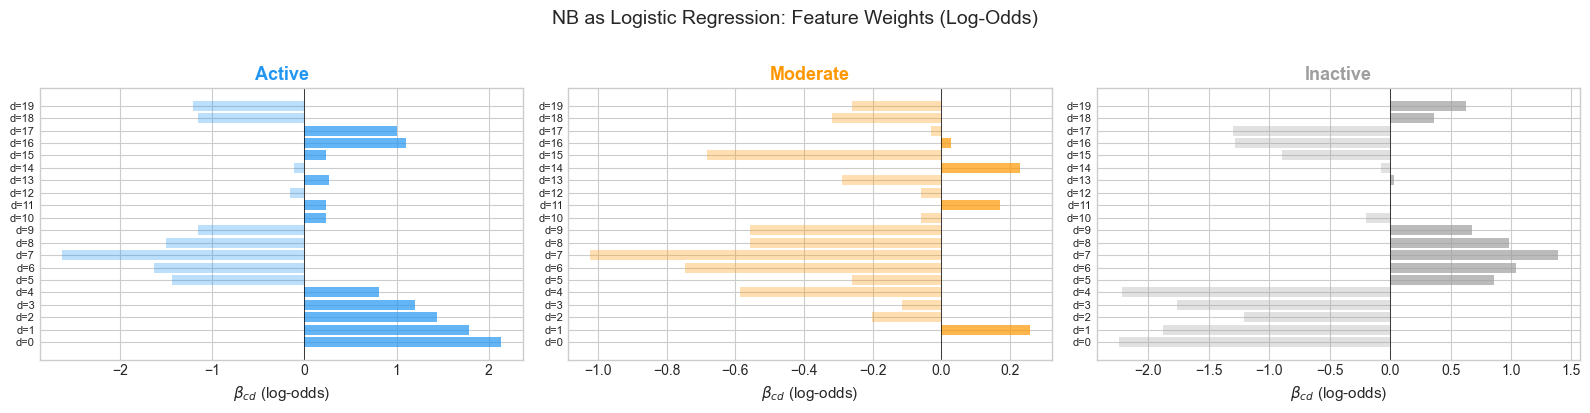

Positive weights: feature presence increases class probability (log-odds > 0).
Negative weights: feature presence decreases class probability.

Active compounds: high weights for pharmacophore features (d=0-4),
negative weights for toxicophore features (d=5-9). Inactive: reversed.


In [14]:
# Visualize the weight vectors — which features are most discriminative?
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for c in range(C):
    ax = axes[c]
    bars = ax.barh(range(D), beta_nb[c], color=colors[c], alpha=0.7)
    
    # Color bars by sign
    for bar, val in zip(bars, beta_nb[c]):
        if val < 0:
            bar.set_alpha(0.3)
    
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_yticks(range(D))
    ax.set_yticklabels([f'd={d}' for d in range(D)], fontsize=8)
    ax.set_xlabel('$\\beta_{cd}$ (log-odds)', fontsize=11)
    ax.set_title(f'{class_names[c]}', fontsize=13, color=colors[c], fontweight='bold')

plt.suptitle('NB as Logistic Regression: Feature Weights (Log-Odds)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Positive weights: feature presence increases class probability (log-odds > 0).")
print("Negative weights: feature presence decreases class probability.")
print("\nActive compounds: high weights for pharmacophore features (d=0-4),")
print("negative weights for toxicophore features (d=5-9). Inactive: reversed.")

## 8. Handling Missing Features (Section 9.4.3)

A major advantage of generative classifiers: they handle **missing data** naturally. If feature $x_1$ is missing, we marginalize it out (Eq. 9.65):

$$\sum_{x_1} p(x_1, x_{2:D} | y = c) = \left[\sum_{x_1} p(x_1 | \theta_{1c})\right] \prod_{d=2}^{D} p(x_d | \theta_{dc}) = \prod_{d=2}^{D} p(x_d | \theta_{dc})$$

Under the naive Bayes assumption, we simply **drop the missing feature** from the likelihood product. No imputation needed.

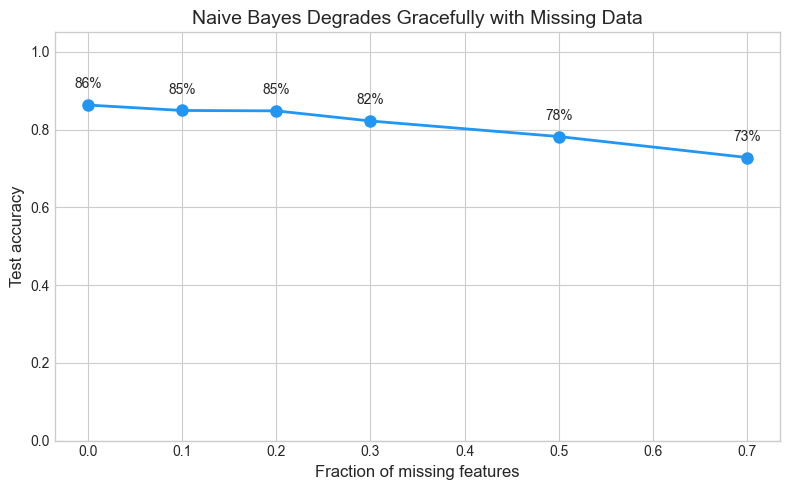

With 30% of features missing, accuracy barely drops.
Even with 50% missing, the model still performs reasonably.

This is a major practical advantage for lab data where assays
often fail or are too expensive to run for every compound.


In [15]:
def predict_bernoulli_nb_missing(X, pi, theta, C, missing_mask):
    """
    Bernoulli NB with missing features (Eq. 9.65).
    
    missing_mask: (N, D) boolean array, True where feature is missing.
    Missing features are simply excluded from the likelihood product.
    """
    N = X.shape[0]
    log_posteriors = np.zeros((N, C))
    
    for c in range(C):
        log_prior = np.log(pi[c])
        
        # Only include observed features in the log-likelihood
        log_lik = X * np.log(theta[c]) + (1 - X) * np.log(1 - theta[c])
        log_lik[missing_mask] = 0  # Missing features contribute 0 to log-likelihood
        
        log_posteriors[:, c] = log_prior + log_lik.sum(axis=1)
    
    preds = np.argmax(log_posteriors, axis=1)
    return preds, log_posteriors


# Simulate missing data at different rates
missing_rates = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7]
accuracies = []

theta_safe_full = np.clip(theta_hat, 1e-10, 1 - 1e-10)

for rate in missing_rates:
    # Randomly mask features
    missing = rng.rand(N_test, D) < rate
    preds_m, _ = predict_bernoulli_nb_missing(X_test, pi_hat, theta_safe_full, C, missing)
    acc = (preds_m == y_test).mean()
    accuracies.append(acc)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(missing_rates, accuracies, 'o-', color=colors[0], linewidth=2, markersize=8)
ax.set_xlabel('Fraction of missing features', fontsize=12)
ax.set_ylabel('Test accuracy', fontsize=12)
ax.set_title('Naive Bayes Degrades Gracefully with Missing Data', fontsize=14)
ax.set_ylim(0, 1.05)

for rate, acc in zip(missing_rates, accuracies):
    ax.annotate(f'{acc:.0%}', (rate, acc), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("With 30% of features missing, accuracy barely drops.")
print("Even with 50% missing, the model still performs reasonably.")
print("\nThis is a major practical advantage for lab data where assays")
print("often fail or are too expensive to run for every compound.")

## 9. Scaling to High Dimensions

A key advantage of naive Bayes: it has only $O(CD)$ parameters, compared to $O(CD^2)$ for GDA with full covariance. Let's see how this plays out as we increase the feature dimensionality.

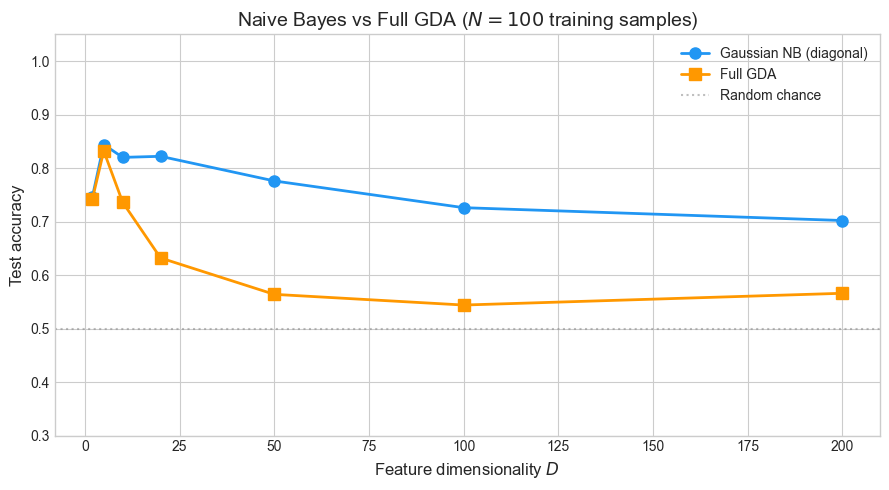

At D=200: NB has 800 parameters, Full GDA has 40,600
With only 100 samples, GDA's covariance estimates become unreliable,
while NB's O(CD) parameters remain well-estimated.


In [16]:
# Compare Naive Bayes vs Full GDA as dimensionality grows
from scipy.stats import multivariate_normal

dims = [2, 5, 10, 20, 50, 100, 200]
N_train = 100  # Intentionally small to show overfitting
N_test_dim = 500

nb_accs = []
gda_accs = []

for D_test in dims:
    # Generate data: 2-class problem with Gaussian features
    mu0 = np.zeros(D_test)
    mu1 = np.zeros(D_test)
    mu1[:5] = 1.0  # Only first 5 features are discriminative
    
    sigma2_true = np.ones(D_test)  # Unit variance per feature
    
    # Training data
    y_tr = rng.choice(2, size=N_train)
    X_tr = np.zeros((N_train, D_test))
    for n in range(N_train):
        X_tr[n] = rng.normal(mu0 if y_tr[n] == 0 else mu1, 1.0)
    
    # Test data
    y_te = rng.choice(2, size=N_test_dim)
    X_te = np.zeros((N_test_dim, D_test))
    for n in range(N_test_dim):
        X_te[n] = rng.normal(mu0 if y_te[n] == 0 else mu1, 1.0)
    
    # Gaussian Naive Bayes (diagonal covariance)
    pi_nb, mu_nb, s2_nb = fit_gaussian_nb(X_tr, y_tr, 2)
    preds_nb, _ = predict_gaussian_nb(X_te, pi_nb, mu_nb, s2_nb, 2)
    nb_accs.append((preds_nb == y_te).mean())
    
    # Full GDA (full covariance per class)
    try:
        mu_gda = []
        Sigma_gda = []
        pi_gda = np.zeros(2)
        for c in range(2):
            mask = y_tr == c
            Nc = mask.sum()
            pi_gda[c] = Nc / N_train
            mu_c = X_tr[mask].mean(axis=0)
            mu_gda.append(mu_c)
            diff = X_tr[mask] - mu_c
            Sigma_c = (diff.T @ diff) / Nc + 1e-4 * np.eye(D_test)  # Small regularization
            Sigma_gda.append(Sigma_c)
        
        # Classify test points
        scores = np.zeros((N_test_dim, 2))
        for c in range(2):
            rv = multivariate_normal(mu_gda[c], Sigma_gda[c], allow_singular=True)
            scores[:, c] = np.log(pi_gda[c]) + rv.logpdf(X_te)
        preds_gda = np.argmax(scores, axis=1)
        gda_accs.append((preds_gda == y_te).mean())
    except Exception:
        gda_accs.append(0.5)  # Random guess if singular

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dims, nb_accs, 'o-', color=colors[0], linewidth=2, markersize=8, label='Gaussian NB (diagonal)')
ax.plot(dims, gda_accs, 's-', color=colors[1], linewidth=2, markersize=8, label='Full GDA')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Random chance')
ax.set_xlabel('Feature dimensionality $D$', fontsize=12)
ax.set_ylabel('Test accuracy', fontsize=12)
ax.set_title(f'Naive Bayes vs Full GDA ($N={N_train}$ training samples)', fontsize=14)
ax.legend(fontsize=10)
ax.set_ylim(0.3, 1.05)
plt.tight_layout()
plt.show()

n_params_nb_200 = 2 * 2 * 200  # C * 2 * D (mean + variance)
n_params_gda_200 = 2 * (200 + 200 * 201 // 2)  # C * (D + D*(D+1)/2)
print(f"At D=200: NB has {n_params_nb_200:,} parameters, Full GDA has {n_params_gda_200:,}")
print(f"With only {N_train} samples, GDA's covariance estimates become unreliable,")
print(f"while NB's O(CD) parameters remain well-estimated.")

## Summary

### Key Takeaways

- **Naive Bayes** assumes features are conditionally independent given the class: $p(\mathbf{x} | y=c) = \prod_d p(x_d | y=c, \theta_{dc})$
- Despite being "naive", it works well because it has only **$O(CD)$ parameters** — immune to the curse of dimensionality
- **Bernoulli NB** models binary features (molecular fingerprints, text indicators)
- **Gaussian NB** models continuous features with diagonal covariances
- **Laplace smoothing** prevents zero probabilities with limited data
- The posterior has the same form as **logistic regression** — same model, different fitting procedure (generative vs discriminative)
- **Missing data** is handled naturally by dropping absent features from the likelihood

### Key Formulas from Chapter 9.3

| Concept | Formula |
|---------|--------|
| Naive Bayes assumption | $p(\mathbf{x} \| y=c) = \prod_d p(x_d \| y=c, \theta_{dc})$ |
| Bernoulli MLE | $\hat{\theta}_{dc} = N_{dc} / N_c$ |
| Gaussian MLE | $\hat{\mu}_{dc} = \frac{1}{N_c}\sum_{n:y_n=c} x_{nd}$, $\hat{\sigma}^2_{dc} = \frac{1}{N_c}\sum_{n:y_n=c}(x_{nd} - \hat{\mu}_{dc})^2$ |
| Laplace smoothing | $\bar{\theta}_{dc} = (1 + N_{dc}) / (2 + N_c)$ |
| NB as logistic regression | $p(y=c \| \mathbf{x}) = \text{softmax}(\boldsymbol{\beta}_c^\top \mathbf{x} + \gamma_c)$ |
| Missing features | Drop missing $x_d$ from $\prod_d$ — marginalization is free |